Using device: cpu


100%|██████████| 170M/170M [00:05<00:00, 32.8MB/s]



############################################################
Configuration: Low Regularization
Lambda: 1e-06, Epochs: 10, LR: 0.001
############################################################

Training Configuration:
  Epochs: 10
  Lambda (regularization): 1e-06
  Learning rate: 0.001
  Temperature schedule: 3.0 -> 0.1

Epoch  1/10 | Loss: 1.9622 | Cls: 1.9622 | Reg: 0.2747 | Acc: 0.1000 | Sparsity: 5.55%
Epoch  2/10 | Loss: 1.8328 | Cls: 1.8328 | Reg: 0.2748 | Acc: 0.1000 | Sparsity: 5.56%
Epoch  3/10 | Loss: 1.7806 | Cls: 1.7806 | Reg: 0.2750 | Acc: 0.1000 | Sparsity: 5.58%
Epoch  4/10 | Loss: 1.7461 | Cls: 1.7461 | Reg: 0.2753 | Acc: 0.1000 | Sparsity: 5.59%
Epoch  5/10 | Loss: 1.7157 | Cls: 1.7157 | Reg: 0.2759 | Acc: 0.1000 | Sparsity: 5.59%
Epoch  6/10 | Loss: 1.7017 | Cls: 1.7017 | Reg: 0.2769 | Acc: 0.1000 | Sparsity: 5.60%
Epoch  7/10 | Loss: 1.6979 | Cls: 1.6979 | Reg: 0.2784 | Acc: 0.1000 | Sparsity: 5.60%
Epoch  8/10 | Loss: 1.7443 | Cls: 1.7443 | Reg: 0.2803 | Acc: 0.100

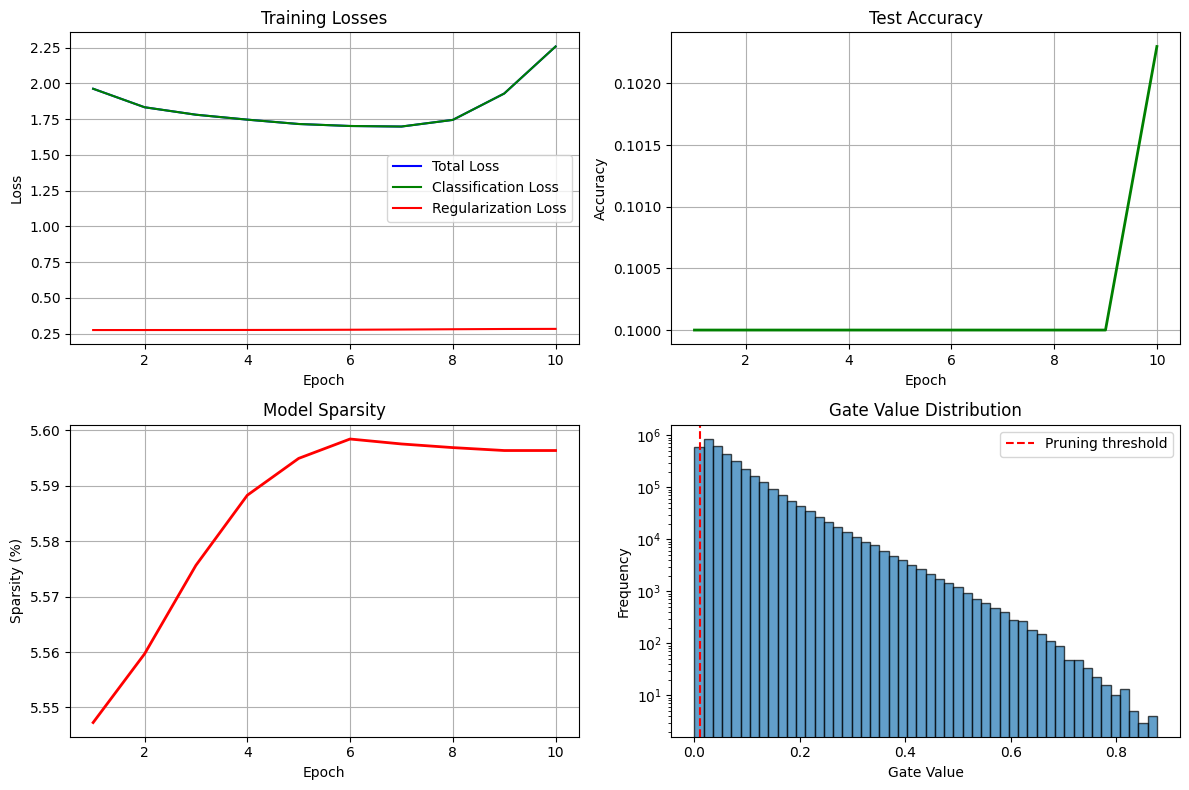


MODEL SUMMARY

layer_0:
  Mean gate value: 0.0689
  Gate std: 0.0682
  Sparsity: 5.61%

layer_1:
  Mean gate value: 0.0692
  Gate std: 0.0682
  Sparsity: 5.52%

layer_2:
  Mean gate value: 0.0693
  Gate std: 0.0679
  Sparsity: 5.48%

layer_3:
  Mean gate value: 0.0755
  Gate std: 0.0726
  Sparsity: 5.23%

Overall Statistics:
  Total parameters: 7,612,682
  Active parameters: 7,186,648
  Model sparsity: 5.60%
  Model size (after pruning): 13.70 MB
  Final test accuracy: 0.1023

############################################################
Configuration: Medium Regularization
Lambda: 1e-05, Epochs: 10, LR: 0.001
############################################################

Training Configuration:
  Epochs: 10
  Lambda (regularization): 1e-05
  Learning rate: 0.001
  Temperature schedule: 3.0 -> 0.1

Epoch  1/10 | Loss: 1.9713 | Cls: 1.9713 | Reg: 0.2785 | Acc: 0.1000 | Sparsity: 5.57%
Epoch  2/10 | Loss: 1.8342 | Cls: 1.8342 | Reg: 0.2786 | Acc: 0.1000 | Sparsity: 5.58%
Epoch  3/10 | Los

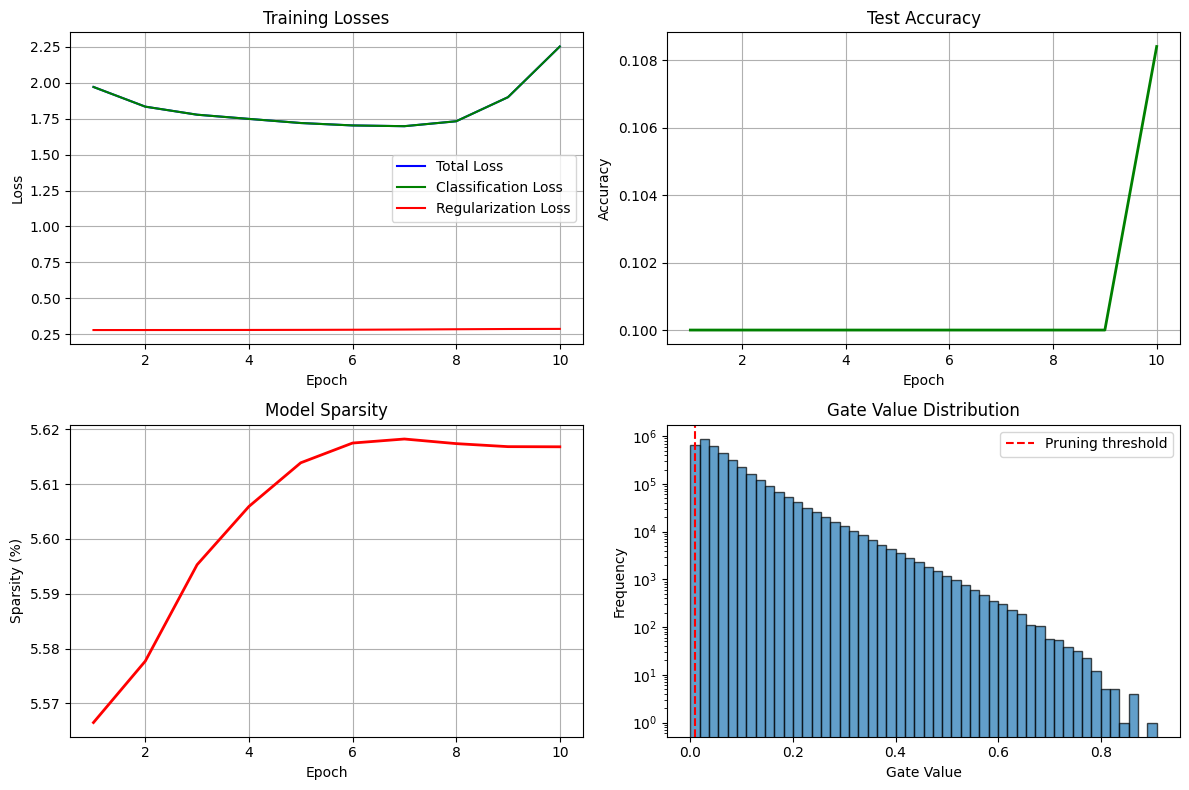


MODEL SUMMARY

layer_0:
  Mean gate value: 0.0689
  Gate std: 0.0681
  Sparsity: 5.63%

layer_1:
  Mean gate value: 0.0692
  Gate std: 0.0683
  Sparsity: 5.58%

layer_2:
  Mean gate value: 0.0693
  Gate std: 0.0676
  Sparsity: 5.49%

layer_3:
  Mean gate value: 0.0792
  Gate std: 0.0791
  Sparsity: 4.73%

Overall Statistics:
  Total parameters: 7,612,682
  Active parameters: 7,185,093
  Model sparsity: 5.62%
  Model size (after pruning): 13.69 MB
  Final test accuracy: 0.1084

############################################################
Configuration: High Regularization
Lambda: 0.0001, Epochs: 10, LR: 0.001
############################################################

Training Configuration:
  Epochs: 10
  Lambda (regularization): 0.0001
  Learning rate: 0.001
  Temperature schedule: 3.0 -> 0.1

Epoch  1/10 | Loss: 1.9618 | Cls: 1.9618 | Reg: 0.2799 | Acc: 0.1000 | Sparsity: 5.57%
Epoch  2/10 | Loss: 1.8323 | Cls: 1.8323 | Reg: 0.2800 | Acc: 0.1000 | Sparsity: 5.59%
Epoch  3/10 | Los

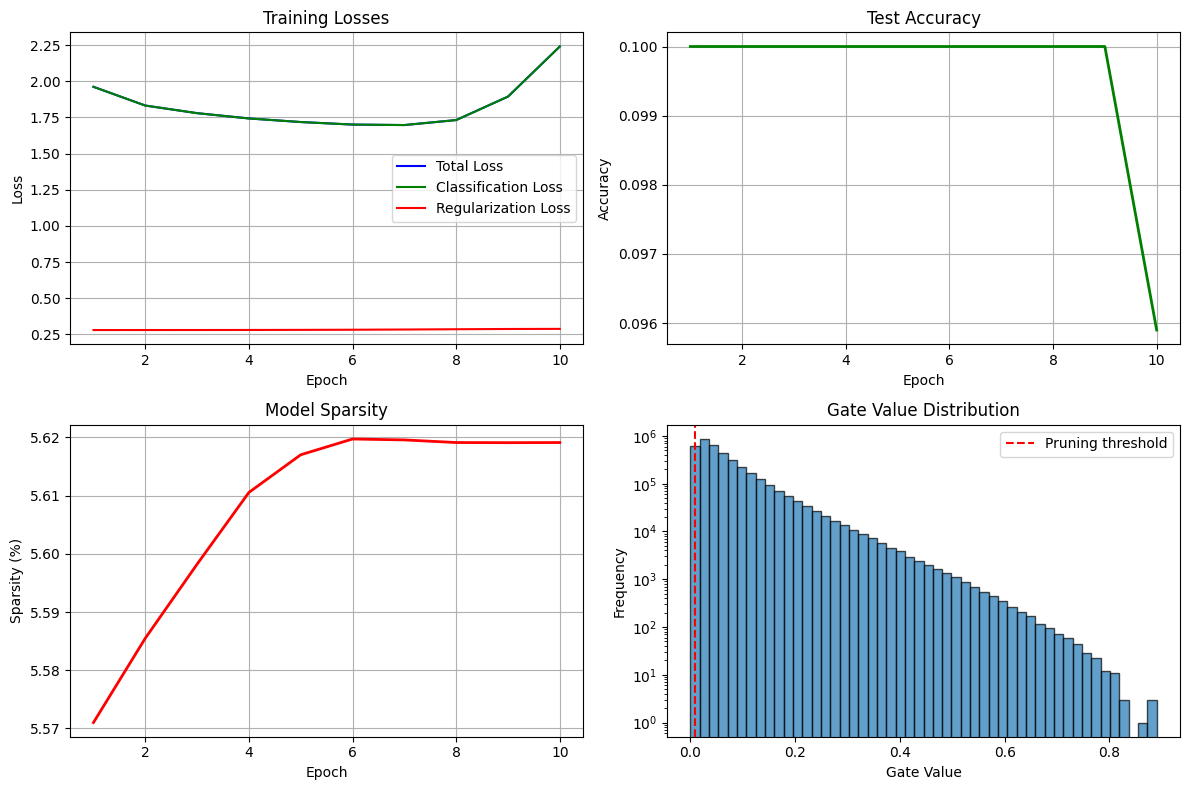


MODEL SUMMARY

layer_0:
  Mean gate value: 0.0688
  Gate std: 0.0682
  Sparsity: 5.62%

layer_1:
  Mean gate value: 0.0692
  Gate std: 0.0683
  Sparsity: 5.60%

layer_2:
  Mean gate value: 0.0693
  Gate std: 0.0683
  Sparsity: 5.65%

layer_3:
  Mean gate value: 0.0806
  Gate std: 0.0831
  Sparsity: 5.47%

Overall Statistics:
  Total parameters: 7,612,682
  Active parameters: 7,184,915
  Model sparsity: 5.62%
  Model size (after pruning): 13.69 MB
  Final test accuracy: 0.0959

BEST CONFIGURATION: Medium Regularization
Best Accuracy: 0.1084

Analyzing Best Model:

MODEL SUMMARY

layer_0:
  Mean gate value: 0.0689
  Gate std: 0.0681
  Sparsity: 5.63%

layer_1:
  Mean gate value: 0.0692
  Gate std: 0.0683
  Sparsity: 5.58%

layer_2:
  Mean gate value: 0.0693
  Gate std: 0.0676
  Sparsity: 5.49%

layer_3:
  Mean gate value: 0.0792
  Gate std: 0.0791
  Sparsity: 4.73%

Overall Statistics:
  Total parameters: 7,612,682
  Active parameters: 7,185,093
  Model sparsity: 5.62%
  Model size (aft

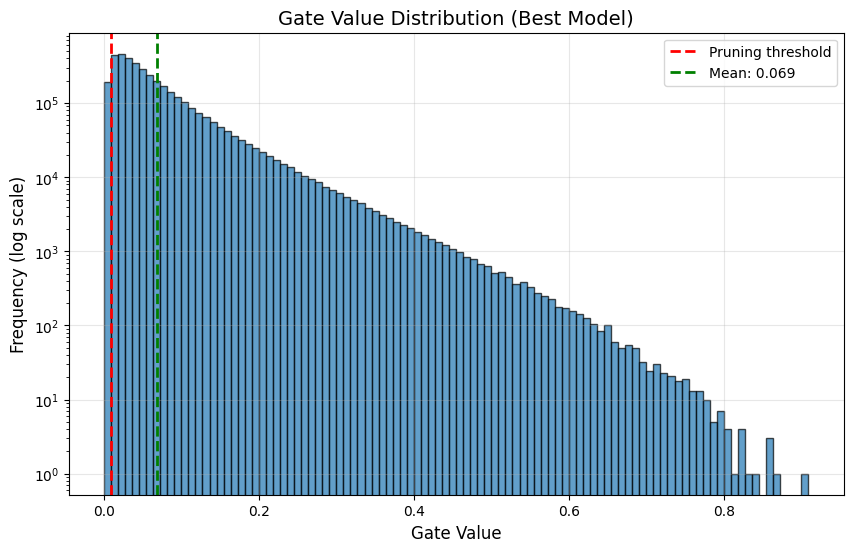

In [1]:
# Improved Self-Pruning Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# 1. Improved Custom Prunable Linear Layer with Learnable Threshold
class ImprovedPrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, init_gate_bias=-3.0):
        super().__init__()

        # He initialization for better gradient flow
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * np.sqrt(2.0 / in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate parameters with bias to start mostly closed
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) + init_gate_bias)

        # Optional: Learnable temperature for annealing
        self.temperature = 1.0

    def forward(self, x, temperature=None):
        # Use temperature for annealing if provided
        temp = temperature if temperature is not None else self.temperature

        # Sigmoid with temperature (higher temp = smoother, lower temp = sharper)
        gates = torch.sigmoid(self.gate_scores / temp)

        # Apply gates to weights
        pruned_weights = self.weight * gates

        # Standard linear operation
        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores)

    def get_pruned_weights(self, threshold=0.01):
        """Get weights after hard pruning at threshold"""
        gates = torch.sigmoid(self.gate_scores)
        mask = (gates > threshold).float()
        return self.weight * mask

# 2. Improved Network with Batch Normalization and Dropout
class ImprovedPrunableMLP(nn.Module):
    def __init__(self, input_size=32*32*3, hidden_sizes=[1024, 512, 256], dropout_rate=0.3):
        super().__init__()

        self.layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()

        prev_size = input_size
        for i, hidden_size in enumerate(hidden_sizes):
            self.layers.append(ImprovedPrunableLinear(prev_size, hidden_size))
            self.bn_layers.append(nn.BatchNorm1d(hidden_size))
            prev_size = hidden_size

        # Output layer
        self.output_layer = ImprovedPrunableLinear(prev_size, 10)
        self.dropout = nn.Dropout(dropout_rate)

        # Store architecture info
        self.hidden_sizes = hidden_sizes

    def forward(self, x, temperature=None):
        # Flatten image
        x = x.view(x.size(0), -1)

        # Forward pass through hidden layers
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x, temperature)
            x = bn(x)
            x = F.relu(x)
            x = self.dropout(x)

        # Output layer (no activation)
        x = self.output_layer(x, temperature)
        return x

    def get_all_gates(self):
        gates = []
        for layer in self.layers:
            gates.append(layer.get_gate_values().view(-1))
        gates.append(self.output_layer.get_gate_values().view(-1))
        return torch.cat(gates)

    def get_layer_gate_stats(self):
        """Get gate statistics per layer"""
        stats = {}
        for i, layer in enumerate(self.layers + [self.output_layer]):
            gates = layer.get_gate_values()
            stats[f'layer_{i}'] = {
                'mean': gates.mean().item(),
                'std': gates.std().item(),
                'sparsity': (gates < 0.01).float().mean().item()
            }
        return stats

# 3. Adaptive Sparsity Loss with different regularization per layer
def compute_adaptive_sparsity_loss(model, layer_lambdas=None):
    """Compute sparsity loss with different regularization strengths per layer"""
    if layer_lambdas is None:
        layer_lambdas = [1.0, 1.0, 1.0, 1.0]  # Default equal weights

    total_reg = 0
    for i, layer in enumerate(model.layers + [model.output_layer]):
        gates = layer.get_gate_values()
        # L1 regularization but normalized by number of gates
        reg = gates.sum() / gates.numel()
        total_reg += layer_lambdas[i] * reg

    return total_reg

# 4. Advanced Training with Cosine Annealing and Gradient Clipping
class PrunableTrainer:
    def __init__(self, model, device, train_loader, test_loader):
        self.model = model
        self.device = device
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.history = defaultdict(list)

    def train_one_epoch(self, optimizer, lambda_reg, epoch, total_epochs, temperature=1.0):
        self.model.train()
        running_loss = 0
        running_cls_loss = 0
        running_reg_loss = 0

        # Anneal temperature over epochs (start high, end low for sharp pruning)
        current_temp = temperature * (1 - epoch / total_epochs)

        for images, labels in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)

            optimizer.zero_grad()

            # Forward pass with current temperature
            outputs = self.model(images, temperature=current_temp)

            # Classification loss (Cross Entropy with label smoothing)
            cls_loss = F.cross_entropy(outputs, labels, label_smoothing=0.1)

            # Adaptive sparsity loss
            reg_loss = compute_adaptive_sparsity_loss(self.model)

            # Total loss with dynamic regularization
            # Increase regularization gradually
            dynamic_lambda = lambda_reg * min(1.0, epoch / 3)
            total_loss = cls_loss + dynamic_lambda * reg_loss

            # Backpropagation with gradient clipping
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += total_loss.item()
            running_cls_loss += cls_loss.item()
            running_reg_loss += reg_loss.item()

        n_batches = len(self.train_loader)
        return {
            'loss': running_loss / n_batches,
            'cls_loss': running_cls_loss / n_batches,
            'reg_loss': running_reg_loss / n_batches
        }

    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images, temperature=0.1)  # Low temp for inference
                predictions = outputs.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        return correct / total

    def compute_sparsity(self, threshold=0.01):
        gates = self.model.get_all_gates()
        total_weights = gates.numel()
        pruned_weights = (gates < threshold).sum().item()
        return 100.0 * pruned_weights / total_weights

    def compute_model_size_mb(self):
        """Calculate actual model size in MB after pruning"""
        total_params = 0
        for layer in self.model.layers + [self.model.output_layer]:
            mask = (layer.get_gate_values() > 0.01).float()
            total_params += mask.sum().item()

        # Assuming 4 bytes per parameter (float32)
        size_mb = (total_params * 4) / (1024 * 1024)
        return size_mb

    def train(self, epochs, lambda_reg, lr=1e-3, temperature_start=5.0):
        optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        print(f"\n{'='*60}")
        print(f"Training Configuration:")
        print(f"  Epochs: {epochs}")
        print(f"  Lambda (regularization): {lambda_reg}")
        print(f"  Learning rate: {lr}")
        print(f"  Temperature schedule: {temperature_start} -> 0.1")
        print(f"{'='*60}\n")

        for epoch in range(epochs):
            # Train
            losses = self.train_one_epoch(
                optimizer, lambda_reg, epoch, epochs,
                temperature=temperature_start
            )
            scheduler.step()

            # Evaluate every epoch
            accuracy = self.evaluate()
            sparsity = self.compute_sparsity()

            # Store history
            self.history['loss'].append(losses['loss'])
            self.history['cls_loss'].append(losses['cls_loss'])
            self.history['reg_loss'].append(losses['reg_loss'])
            self.history['accuracy'].append(accuracy)
            self.history['sparsity'].append(sparsity)

            # Print progress
            print(f"Epoch {epoch+1:2d}/{epochs} | "
                  f"Loss: {losses['loss']:.4f} | "
                  f"Cls: {losses['cls_loss']:.4f} | "
                  f"Reg: {losses['reg_loss']:.4f} | "
                  f"Acc: {accuracy:.4f} | "
                  f"Sparsity: {sparsity:.2f}%")

        return self.history

    def plot_training_history(self):
        """Plot training metrics"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        epochs = range(1, len(self.history['loss']) + 1)

        # Loss plot
        axes[0,0].plot(epochs, self.history['loss'], 'b-', label='Total Loss')
        axes[0,0].plot(epochs, self.history['cls_loss'], 'g-', label='Classification Loss')
        axes[0,0].plot(epochs, self.history['reg_loss'], 'r-', label='Regularization Loss')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].set_title('Training Losses')
        axes[0,0].legend()
        axes[0,0].grid(True)

        # Accuracy plot
        axes[0,1].plot(epochs, self.history['accuracy'], 'g-', linewidth=2)
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Accuracy')
        axes[0,1].set_title('Test Accuracy')
        axes[0,1].grid(True)

        # Sparsity plot
        axes[1,0].plot(epochs, self.history['sparsity'], 'r-', linewidth=2)
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Sparsity (%)')
        axes[1,0].set_title('Model Sparsity')
        axes[1,0].grid(True)

        # Gate distribution histogram (final)
        gates = self.model.get_all_gates().cpu().detach().numpy()
        axes[1,1].hist(gates, bins=50, alpha=0.7, edgecolor='black')
        axes[1,1].axvline(x=0.01, color='r', linestyle='--', label='Pruning threshold')
        axes[1,1].set_xlabel('Gate Value')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Gate Value Distribution')
        axes[1,1].legend()
        axes[1,1].set_yscale('log')

        plt.tight_layout()
        plt.show()

    def print_model_summary(self):
        """Print detailed model summary"""
        print("\n" + "="*60)
        print("MODEL SUMMARY")
        print("="*60)

        # Layer-wise gate statistics
        layer_stats = self.model.get_layer_gate_stats()
        for layer_name, stats in layer_stats.items():
            print(f"\n{layer_name}:")
            print(f"  Mean gate value: {stats['mean']:.4f}")
            print(f"  Gate std: {stats['std']:.4f}")
            print(f"  Sparsity: {stats['sparsity']*100:.2f}%")

        # Overall statistics
        total_sparsity = self.compute_sparsity()
        model_size = self.compute_model_size_mb()
        total_params = sum(p.numel() for p in self.model.parameters())
        active_params = int(total_params * (1 - total_sparsity/100))

        print(f"\nOverall Statistics:")
        print(f"  Total parameters: {total_params:,}")
        print(f"  Active parameters: {active_params:,}")
        print(f"  Model sparsity: {total_sparsity:.2f}%")
        print(f"  Model size (after pruning): {model_size:.2f} MB")
        print(f"  Final test accuracy: {self.history['accuracy'][-1]:.4f}")
        print("="*60)

# 5. Main Training Script with Multiple Configurations
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Data preprocessing with augmentation
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Load CIFAR-10 dataset
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

    # Try different configurations
    configs = [
        {'lambda': 1e-6, 'epochs': 10, 'lr': 1e-3, 'name': 'Low Regularization'},
        {'lambda': 1e-5, 'epochs': 10, 'lr': 1e-3, 'name': 'Medium Regularization'},
        {'lambda': 1e-4, 'epochs': 10, 'lr': 1e-3, 'name': 'High Regularization'},
    ]

    best_accuracy = 0
    best_config = None

    for config in configs:
        print(f"\n{'#'*60}")
        print(f"Configuration: {config['name']}")
        print(f"Lambda: {config['lambda']}, Epochs: {config['epochs']}, LR: {config['lr']}")
        print(f"{'#'*60}")

        # Initialize model
        model = ImprovedPrunableMLP(
            input_size=32*32*3,
            hidden_sizes=[1024, 512, 256],
            dropout_rate=0.3
        ).to(device)

        # Create trainer
        trainer = PrunableTrainer(model, device, train_loader, test_loader)

        # Train model
        history = trainer.train(
            epochs=config['epochs'],
            lambda_reg=config['lambda'],
            lr=config['lr'],
            temperature_start=3.0
        )

        # Final evaluation
        final_accuracy = history['accuracy'][-1]
        final_sparsity = history['sparsity'][-1]

        print(f"\nResults for {config['name']}:")
        print(f"  Final Accuracy: {final_accuracy:.4f}")
        print(f"  Final Sparsity: {final_sparsity:.2f}%")

        # Track best model
        if final_accuracy > best_accuracy:
            best_accuracy = final_accuracy
            best_config = config
            best_trainer = trainer

        # Plot history
        trainer.plot_training_history()
        trainer.print_model_summary()

    # Show best configuration
    print(f"\n{'='*60}")
    print(f"BEST CONFIGURATION: {best_config['name']}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"{'='*60}")

    # Analyze the best model
    print("\nAnalyzing Best Model:")
    best_trainer.print_model_summary()

    # Show gate distribution for best model
    gates = best_trainer.model.get_all_gates().cpu().detach().numpy()
    plt.figure(figsize=(10, 6))
    plt.hist(gates, bins=100, alpha=0.7, edgecolor='black', log=True)
    plt.axvline(x=0.01, color='r', linestyle='--', linewidth=2, label='Pruning threshold')
    plt.axvline(x=np.mean(gates), color='g', linestyle='--', linewidth=2, label=f'Mean: {np.mean(gates):.3f}')
    plt.xlabel('Gate Value', fontsize=12)
    plt.ylabel('Frequency (log scale)', fontsize=12)
    plt.title('Gate Value Distribution (Best Model)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()